# sales_intelligence.ipynb

This notebook analyses the sales of Energical, and gives all the necessery KPIs and analysis to have clean insights and make business decisions.

In [1]:
import pandas as pd

import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose


In [ ]:
clean_customers

In [ ]:
clean_customers = clean_customers.rename(columns={
    "Code Client": "customer_id_stage"
})

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
from pipeline.kpis.contract import REALIZED_SALES_STATUSES, filter_realized_sales
VALID_SALES_STATUSES = REALIZED_SALES_STATUSES

valid_sales = clean_orders.loc[
    clean_orders["order_status"].isin(VALID_SALES_STATUSES)
].copy()
valid_sales["order_date"] = pd.to_datetime(
    valid_sales["order_date"],
    errors="coerce"
)

assert set(valid_sales["order_status"].dropna().unique()).issubset(
    set(VALID_SALES_STATUSES)
)

## Sales number

In [ ]:
def sale_number(valid_sales):
    sales_number=valid_sales['order_total_amount'].sum()
    return sales_number

In [ ]:
sale_number(valid_sales)

np.float64(316518834.02)

## Sales growth/trend

In [ ]:
def Sales_growth(current_sales_number,previous_sales_number):
    if previous_sales_number==0:
        return None
    else:
        sales_growth=((current_sales_number-previous_sales_number)/previous_sales_number)*100
    return sales_growth

## Average basket value

In [ ]:
def avg_basket_value(clean_customers):
    customers = clean_customers.copy()
    customers["average_basket"] = (
        customers["total_amount"] / customers["orders_count"]
    )

    return customers

## Sales performance

In [ ]:
#performance per method of payment
def performance_per_mop(Valid_sales):
    performance = (
        Valid_sales
        .groupby("payment_method_group")
        .agg(
            Revenue=("order_total_amount", "sum"),
            Orders=("order_id_stage", "nunique"),
            Average_Basket=("order_total_amount", "mean")
        )
        .reset_index()
    )

    return performance

In [ ]:
shipping_per_order = (
    clean_transactions[["order_id_stage", "shipping_method"]]
    .drop_duplicates()
)
orders_shipping=(
    valid_sales
    .merge(shipping_per_order, on="order_id_stage", how="left")
)

In [ ]:
#performance per delivery method
def performance_per_delivery_method(orders_shipping):
    performance = (
        orders_shipping.groupby("shipping_method").agg(
            Revenue=("order_total_amount", "sum"),
            Orders=("order_id_stage", "nunique"),
            Average_Basket=("order_total_amount", "mean")
        )
        .reset_index()
    )

    return performance


In [ ]:
def performance_per_customer_type(valid_sales):
    performance = (
        valid_sales
        .groupby("customer_type_inferred", as_index=False)
        .agg(
            Customers=("customer_id_stage", "nunique"),
            Revenue=("order_total_amount", "sum"),
            Orders=("order_id_stage", "nunique"),
        )
    )

    performance["Average_Basket"] = (
        performance["Revenue"] / performance["Orders"]
    )

    return performance

## Return rate vs completed sales

In [ ]:
status_mapping = {
    "Terminée": "Completed",
    "En cours": "In Progress",
    "En livraison par NOEST": "In Progress",

    "En attente": "Pending",
    "Attente paiement": "Pending",
    "Partiellement payé": "Pending",

    "Retour NOEST": "Returned",
    "Remboursée": "Refunded",
    "Partiellement remboursée": "Partially Refunded"
}
clean_orders["sales_status"] = clean_orders["order_status"].map(status_mapping)

In [ ]:
def sales_status(clean_orders):

    sales_status = (
        clean_orders.groupby("sales_status")
        .agg(
            orders_count=("order_id_stage", "nunique")
        )
        .reset_index()
    )

    sales_status["percentage"] = (
        sales_status["orders_count"]
        / sales_status["orders_count"].sum()
    ) * 100

    sales_status["percentage"] = sales_status["percentage"].round(2)

    return sales_status

## Negative-price flag - pending validation

"has_negative_price" has not been confirmed to represent a discount.
The following experiment is retained for traceability only and is excluded
from finalized business conclusions.

In [ ]:
# Keep the source field name: its business meaning is not yet validated.
# This experimental section must not relabel has_negative_price as a discount.

In [ ]:
def negative_price_flag_performance(clean_transactions, valid_sales):

    # Create one row per order indicating whether it contains a negative-price line.
    negative_price_orders = (
        clean_transactions.groupby("order_id_stage")["has_negative_price"]
        .any()
        .reset_index()
        .rename(columns={"has_negative_price": "order_has_negative_price"})
    )

    # Keep the same realized-sales population used by the other sales analyses.
    orders = valid_sales.merge(
        negative_price_orders,
        on="order_id_stage",
        how="left"
    )

    # Orders with no negative-price line become False.
    orders["order_has_negative_price"] = (
        orders["order_has_negative_price"].astype("boolean").fillna(False).astype(bool)
    )

    # Aggregate at the order level
    impact = (
        orders.groupby("order_has_negative_price")
        .agg(
            Total_Revenue=("order_total_amount", "sum"),
            Total_Orders=("order_id_stage", "nunique"),
            Average_Order_Value=("order_total_amount", "mean")
        )
        .reset_index()
    )

    return impact

In [ ]:
negative_price_flag_performance(clean_transactions, valid_sales)

,order_has_negative_price,Total_Revenue,Total_Orders,Average_Order_Value
0,False,3.142809e+08,8772,35827.736482
1,True,2.237930e+06,59,37931.010169


## Free Shipping Order Performance

In [ ]:
def free_shipping_performance(clean_transactions, valid_sales):
    free_shipping_orders = (
        clean_transactions.groupby("order_id_stage")["free_shipping"]
        .any()
        .reset_index()
        .rename(columns={"free_shipping": "order_has_free_shipping"})
    )
    
    orders = valid_sales.merge(
        free_shipping_orders,
        on="order_id_stage",
        how="left"
    )
    

    orders["order_has_free_shipping"] = (
        orders["order_has_free_shipping"].astype("boolean").fillna(False).astype(bool)
    )
    impact = (
        orders.groupby("order_has_free_shipping")
        .agg(
            Total_Revenue=("order_total_amount", "sum"),
            Total_Orders=("order_id_stage", "nunique"),
            Average_Order_Value=("order_total_amount", "mean")
        )
        .reset_index()
    )

    return impact

In [ ]:
free_shipping_performance(clean_transactions, valid_sales)

,order_has_free_shipping,Total_Revenue,Total_Orders,Average_Order_Value
0,False,1.084977e+08,7081,15322.374309
1,True,2.080211e+08,1750,118869.200880


# Graphs

### sales number

In [ ]:
# valid_sales.order_date was normalized when the canonical population was defined.
valid_sales["order_date"] = pd.to_datetime(valid_sales["order_date"], errors="coerce")

In [ ]:
sales = (
    valid_sales.assign(
        order_month=valid_sales["order_date"].dt.to_period("M")
    )
    .groupby("order_month", as_index=False)["order_total_amount"]
    .sum()
    .rename(columns={"order_month": "order_date"})
)
sales["order_date"] = sales["order_date"].dt.to_timestamp()
fig = px.line(
    sales,
    x="order_date",
    y="order_total_amount",
    markers='markers',
    title="Monthly Realized Sales"
)

fig.show()

## Customer Type Performance

customer_type_inferred is an inferred field, not verified ground truth.

In [ ]:
b2b_b2c = performance_per_customer_type(valid_sales)

In [ ]:
perf = performance_per_customer_type(valid_sales)

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Revenue", "Orders", "Average Basket")
)

fig.add_trace(
    go.Bar(x=perf["customer_type_inferred"], y=perf["Revenue"], name="Revenue"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=perf["customer_type_inferred"], y=perf["Orders"], name="Orders"),
    row=1, col=2
)
fig.add_trace(
    go.Bar(x=perf["customer_type_inferred"], y=perf["Average_Basket"], name="Average Basket"),
    row=1, col=3
)

fig.update_layout(title_text="Customer Type Performance", showlegend=False)
fig.show()

In [ ]:
perf = performance_per_mop(valid_sales)
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Revenue", "Orders", "Average Basket")
)

fig.add_trace(
    go.Bar(x=perf["payment_method_group"], y=perf["Revenue"], name="Revenue"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=perf["payment_method_group"], y=perf["Orders"], name="Orders"),
    row=1, col=2
)
fig.add_trace(
    go.Bar(x=perf["payment_method_group"], y=perf["Average_Basket"], name="Average Basket"),
    row=1, col=3
)

fig.update_layout(title_text="Payment Method Performance", showlegend=False)
fig.show()

In [ ]:
perf = performance_per_delivery_method(orders_shipping)
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Revenue", "Orders", "Average Basket")
)

fig.add_trace(
    go.Bar(x=perf["shipping_method"], y=perf["Revenue"], name="Revenue"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=perf["shipping_method"], y=perf["Orders"], name="Orders"),
    row=1, col=2
)
fig.add_trace(
    go.Bar(x=perf["shipping_method"], y=perf["Average_Basket"], name="Average Basket"),
    row=1, col=3
)

fig.update_layout(title_text="Delivery Method Performance", showlegend=False)
fig.show()

In [ ]:
sales_status(clean_orders)

,sales_status,orders_count,percentage
0,Completed,8807,95.26
1,In Progress,251,2.71
2,Partially Refunded,24,0.26
3,Pending,11,0.12
4,Refunded,21,0.23
5,Returned,131,1.42


In [ ]:
fig= px.pie(
    sales_status(clean_orders),
    names='sales_status',
    values='orders_count',
    title="Order Status Distribution",
)
fig.show()

In [ ]:
impact = free_shipping_performance(clean_transactions, valid_sales)
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Revenue", "Orders", "Average Basket")
)

fig.add_trace(
    go.Bar(x=impact["order_has_free_shipping"], y=impact["Total_Revenue"], name="Revenue"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=impact["order_has_free_shipping"], y=impact["Total_Orders"], name="Orders"),
    row=1, col=2
)
fig.add_trace(
    go.Bar(x=impact["order_has_free_shipping"], y=impact["Average_Order_Value"], name="Average Basket"),
    row=1, col=3
)

fig.update_layout(title_text="Free Shipping Order Performance", showlegend=False)
fig.show()

In [ ]:
impact = negative_price_flag_performance(clean_transactions, valid_sales)
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Revenue", "Orders", "Average Basket")
)

fig.add_trace(
    go.Bar(x=impact["order_has_negative_price"], y=impact["Total_Revenue"], name="Revenue"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=impact["order_has_negative_price"], y=impact["Total_Orders"], name="Orders"),
    row=1, col=2
)
fig.add_trace(
    go.Bar(x=impact["order_has_negative_price"], y=impact["Average_Order_Value"], name="Average Basket"),
    row=1, col=3
)

fig.update_layout(title_text="Negative-price Flag Analysis (Pending Validation)", showlegend=False)
fig.show()

The sales-performance tables and charts above use the canonical valid_sales population.
The Order Status Distribution intentionally uses all orders so that status composition is preserved.
Free-shipping results are associations only, and the negative-price flag remains pending semantic validation.

# Part 02: Forecasting & Prediction

In [ ]:
# Build the forecasting input from the canonical realized-sales population.
sales = valid_sales[["order_date", "order_total_amount"]].copy()

In [ ]:
sales["order_date"] = pd.to_datetime(sales["order_date"], errors="coerce")

In [ ]:
monthly_sales = (
    sales.assign(
        order_month=sales["order_date"].dt.to_period("M")
    )
    .groupby("order_month", as_index=False)["order_total_amount"]
    .sum()
    .rename(columns={"order_month": "order_date"})
)
monthly_sales["order_date"] = monthly_sales["order_date"].dt.to_timestamp()

# Explicit completeness rule supplied for the current dataset: July 2026 is partial.
COMPLETE_MONTH_END = pd.Timestamp("2026-06-30")
complete_month_period = COMPLETE_MONTH_END.to_period("M")
monthly_sales_all = monthly_sales.copy()
partial_month_sales = monthly_sales_all.loc[monthly_sales_all["order_date"].dt.to_period("M") > complete_month_period].copy()
monthly_sales = monthly_sales_all.loc[monthly_sales_all["order_date"].dt.to_period("M") <= complete_month_period].copy()
assert not monthly_sales.empty
assert monthly_sales["order_date"].dt.to_period("M").max() == complete_month_period
print("Last complete month:", COMPLETE_MONTH_END)
print("Partial months excluded from forecasting:", partial_month_sales["order_date"].dt.strftime("%Y-%m").tolist())


Last complete month: 2026-06-30 00:00:00
Partial months excluded from forecasting: ['2026-07']


In [ ]:
monthly_sales.head()

,order_date,order_total_amount
0,2021-10-01,130095.0
1,2021-11-01,46545.0
2,2021-12-01,460174.0
3,2022-01-01,81960.0
4,2022-02-01,610983.0


In [ ]:
fig= px.line(
    monthly_sales,
    x="order_date",
    y="order_total_amount",
    title="Monthly Realized Sales"
)
fig.show()

In [ ]:
monthly_sales["order_total_amount"].min()

np.float64(46545.0)

### Decomposition

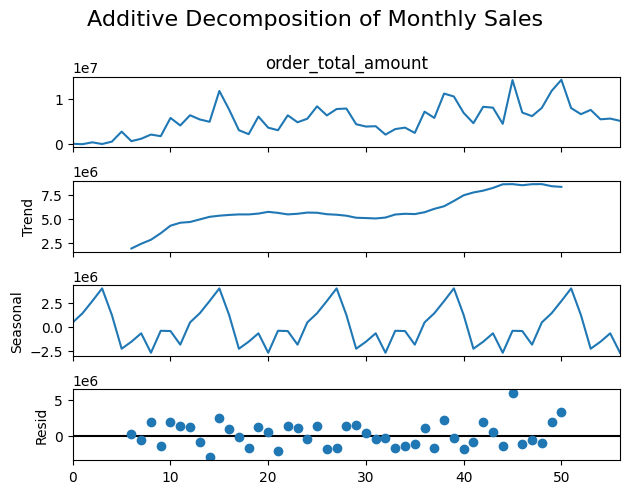

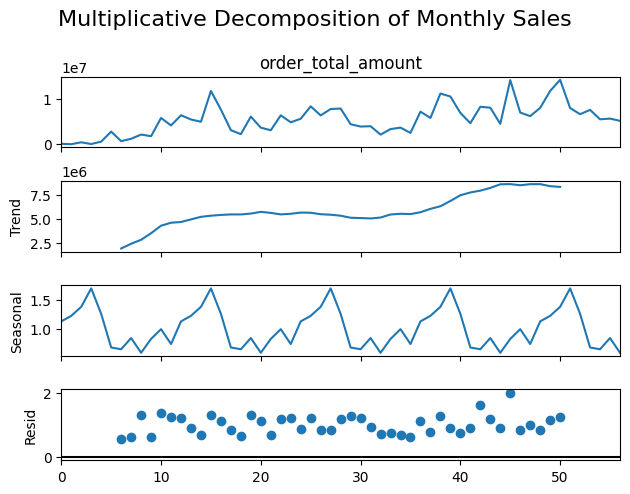

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

additive = seasonal_decompose(
    monthly_sales["order_total_amount"],
    model="additive",
    period=12
)

multiplicative = seasonal_decompose(
    monthly_sales["order_total_amount"],
    model="multiplicative",
    period=12
)
fig_add=additive.plot()
fig_multi=multiplicative.plot()
fig_add.suptitle("Additive Decomposition of Monthly Sales", fontsize=16,
    y=1.02)
fig_multi.suptitle("Multiplicative Decomposition of Monthly Sales", fontsize=16,
                   y=1.02)
fig_multi.subplots_adjust(top=0.88)
fig_add.subplots_adjust(top=0.88)

### Stationarity test

In [ ]:
#log transformation to stabilize variance
monthly_sales_no_var=monthly_sales.copy()
monthly_sales_no_var["order_total_amount"]=np.log(monthly_sales["order_total_amount"])

In [ ]:
# First difference to remove trend
monthly_sales_no_var_no_trend=monthly_sales_no_var.copy()
monthly_sales_no_var_no_trend["order_total_amount"]=monthly_sales_no_var["order_total_amount"].diff()
fig=px.line(
    monthly_sales_no_var_no_trend,
    x="order_date",
    y="order_total_amount"
)
fig.show()

In [ ]:
#test for stationarity using Augmented Dickey-Fuller test
def adf_test(monthly_sales_no_var_no_trend):
    test_results = adfuller(monthly_sales_no_var_no_trend["order_total_amount"].dropna())
    print('ADF Statistic: ', test_results[0])
    print('P-Value: ', test_results[1])
    print('Critical Values:')
    for thres, adf_stat in test_results[4].items():
        print('\t%s: %.2f' % (thres, adf_stat))


adf_test(monthly_sales_no_var_no_trend)

ADF Statistic:  -8.308704483306608
P-Value:  3.8407694953051984e-13
Critical Values:
	1%: -3.56
	5%: -2.92
	10%: -2.60


## Auto-correlation

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

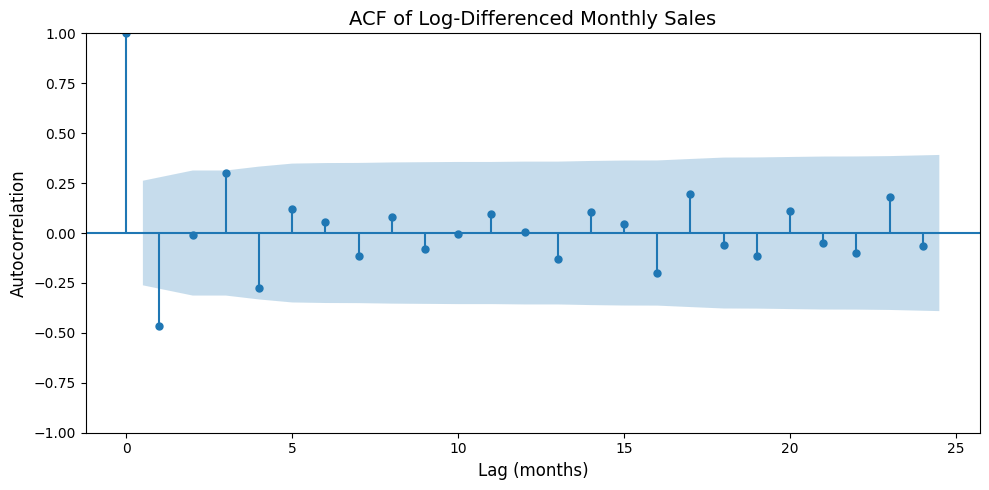

In [ ]:

series = monthly_sales_no_var_no_trend["order_total_amount"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    series,
    lags=24,
    ax=ax,
    alpha=0.05
)

ax.set_ylim(-1, 1)
ax.set_xlabel("Lag (months)", fontsize=12)
ax.set_ylabel("Autocorrelation", fontsize=12)
ax.set_title("ACF of Log-Differenced Monthly Sales", fontsize=14)

ax.tick_params(axis="both", labelsize=10)

fig.tight_layout()
plt.show()

### PACF: Partial autocorrelation function

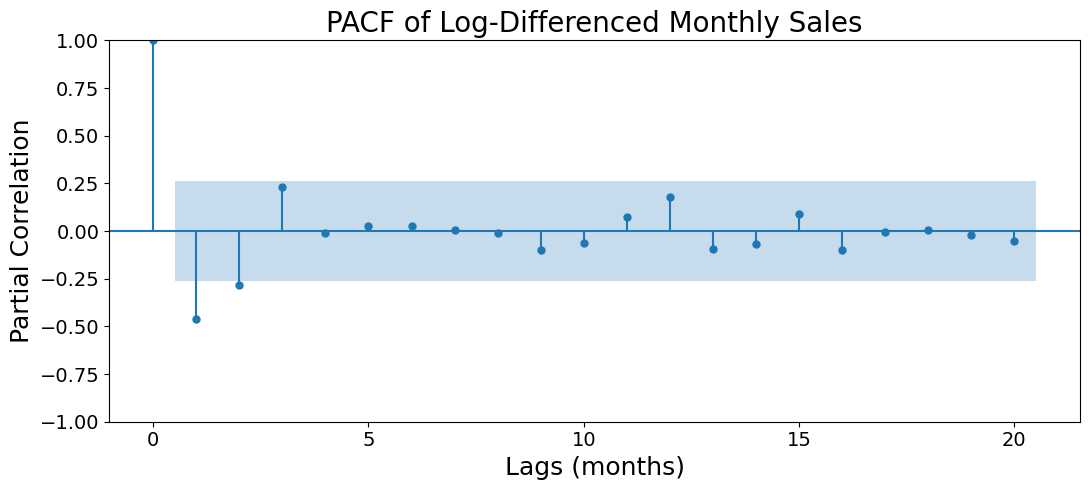

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.rc("figure", figsize=(11, 5))

plot_pacf(
    series,
    lags=20,
    method="ywm"
)

plt.ylim(-1, 1)
plt.xlabel("Lags (months)", fontsize=18)
plt.ylabel("Partial Correlation", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title(
    "PACF of Log-Differenced Monthly Sales",
    fontsize=20
)

plt.tight_layout()
plt.show()

ACF  → strong lag 1, most later lags weak
PACF → strong lag 1, maybe lag 2, most later lags weak

### Basic Forecasting Methods

### Chronological train/test split

In [ ]:
monthly_sales = monthly_sales.sort_values("order_date").reset_index(drop=True)
test_size = int(len(monthly_sales) * 0.20)

train = monthly_sales.iloc[:-test_size].copy()
test = monthly_sales.iloc[-test_size:].copy()

print("Total months:", len(monthly_sales))
print("Training months:", len(train))
print("Testing months:", len(test))

print("Train ends:", train["order_date"].iloc[-1])
print("Test starts:", test["order_date"].iloc[0])

Total months: 57
Training months: 46
Testing months: 11
Train ends: 2025-07-01 00:00:00
Test starts: 2025-08-01 00:00:00


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

#### Average 

In [ ]:
test["average_forecast"] = train["order_total_amount"].mean()

#### Naive

In [ ]:
test["naive_forecast"] = train["order_total_amount"].iloc[-1]

#### Seasonal naive

In [ ]:
train['month_number'] = pd.DatetimeIndex(train['order_date']).month
test['month_number'] = pd.DatetimeIndex(test['order_date']).month

snaive_fc = []
for row_idx, row in test.iterrows():
    month = row['month_number']
    forecast = train['order_total_amount'] .loc[train['month_number'] == month].iloc[-1]
    snaive_fc.append(forecast)

test["seasonal_naive_forecast"] = snaive_fc

#### Drift model

In [ ]:
constant = (
    train["order_total_amount"].iloc[-1]
    - train["order_total_amount"].iloc[0]
) / (len(train) - 1)

test["h"] = range(1, len(test) + 1)

test["drift_forecast"] = (
    train["order_total_amount"].iloc[-1]
    + test["h"] * constant
)

##### Evaluation metrics

,order_date,order_total_amount,average_forecast,naive_forecast,seasonal_naive_forecast,drift_forecast
46,2025-08-01,7021461.80,4.957445e+06,14179432.36,3701456.58,1.449164e+07
47,2025-09-01,6235186.70,4.957445e+06,14179432.36,2538111.40,1.480385e+07
48,2025-10-01,8058357.60,4.957445e+06,14179432.36,7221094.26,1.511605e+07
49,2025-11-01,11793503.60,4.957445e+06,14179432.36,5838479.94,1.542826e+07
50,2025-12-01,14245785.60,4.957445e+06,14179432.36,11212186.92,1.574047e+07
51,2026-01-01,8014037.50,4.957445e+06,14179432.36,10566654.84,1.605268e+07
52,2026-02-01,6663164.42,4.957445e+06,14179432.36,6947639.54,1.636488e+07
53,2026-03-01,7617337.20,4.957445e+06,14179432.36,4684809.52,1.667709e+07
54,2026-04-01,5534853.60,4.957445e+06,14179432.36,8295489.22,1.698930e+07
55,2026-05-01,5693413.70,4.957445e+06,14179432.36,8100653.00,1.730151e+07


,Model,MAE,RMSE
0,Seasonal Naive,2.585593e+06,3.001609e+06
1,Average,2.867641e+06,3.917026e+06
2,Naive,6.366411e+06,6.891839e+06
3,Drift,8.227591e+06,8.818295e+06


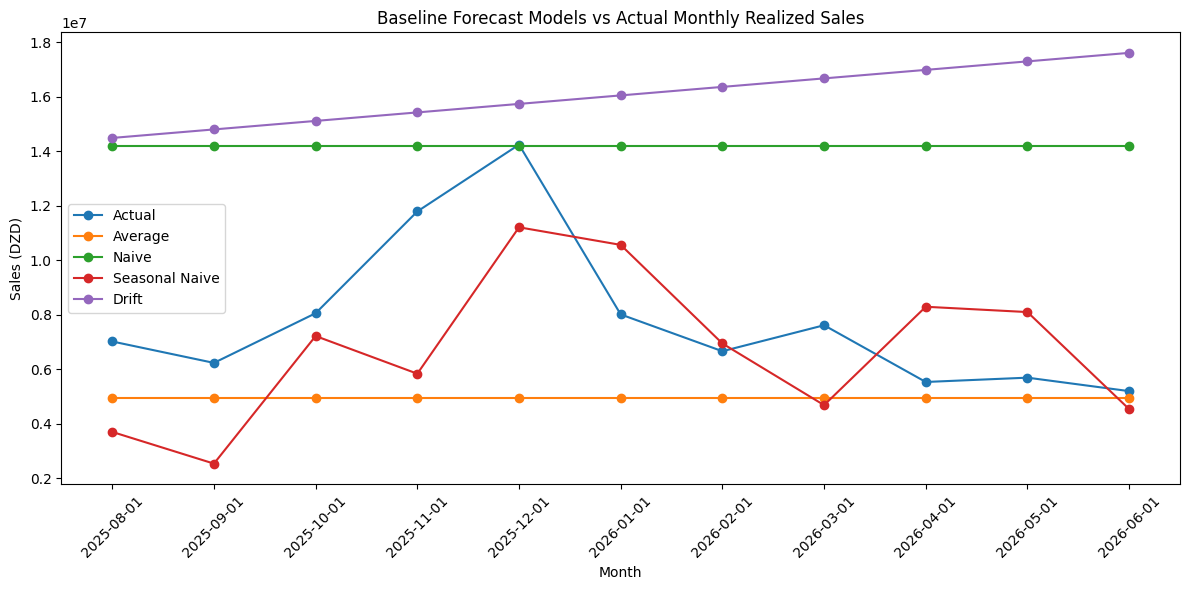

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = test["order_total_amount"]
models = {
    "Average": test["average_forecast"],
    "Naive": test["naive_forecast"],
    "Seasonal Naive": test["seasonal_naive_forecast"],
    "Drift": test["drift_forecast"]
}

results = []
for model_name, forecast in models.items():
    results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(actual, forecast),
        "RMSE": np.sqrt(mean_squared_error(actual, forecast))
    })

results = (
    pd.DataFrame(results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

forecast_table = test[[
    "order_date",
    "order_total_amount",
    "average_forecast",
    "naive_forecast",
    "seasonal_naive_forecast",
    "drift_forecast"
]]
display(forecast_table)
display(results)

plt.figure(figsize=(12, 6))
plt.plot(test["order_date"].astype(str), actual, marker="o", label="Actual")
for model_name, forecast in models.items():
    plt.plot(
        test["order_date"].astype(str),
        forecast,
        marker="o",
        label=model_name
    )
plt.title("Baseline Forecast Models vs Actual Monthly Realized Sales")
plt.xlabel("Month")
plt.ylabel("Sales (DZD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


The baseline comparison above evaluates all four methods on the same chronological held-out period. The Naive forecast remains the benchmark for comparison with SES and the existing ARIMA candidates.

#### Simple Exponential Smoothing

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Fit SES on training data
ses_model = SimpleExpSmoothing(
    train["order_total_amount"]
).fit(optimized=True)

# Forecast the test period
test["ses_forecast"] = ses_model.forecast(len(test)).to_numpy()
ses_mae = mean_absolute_error(actual, test["ses_forecast"])
ses_rmse = np.sqrt(mean_squared_error(actual, test["ses_forecast"]))
print("SES MAE:", ses_mae)
print("SES RMSE:", ses_rmse)

SES MAE: 3176608.1290874314
SES RMSE: 3348768.806774126


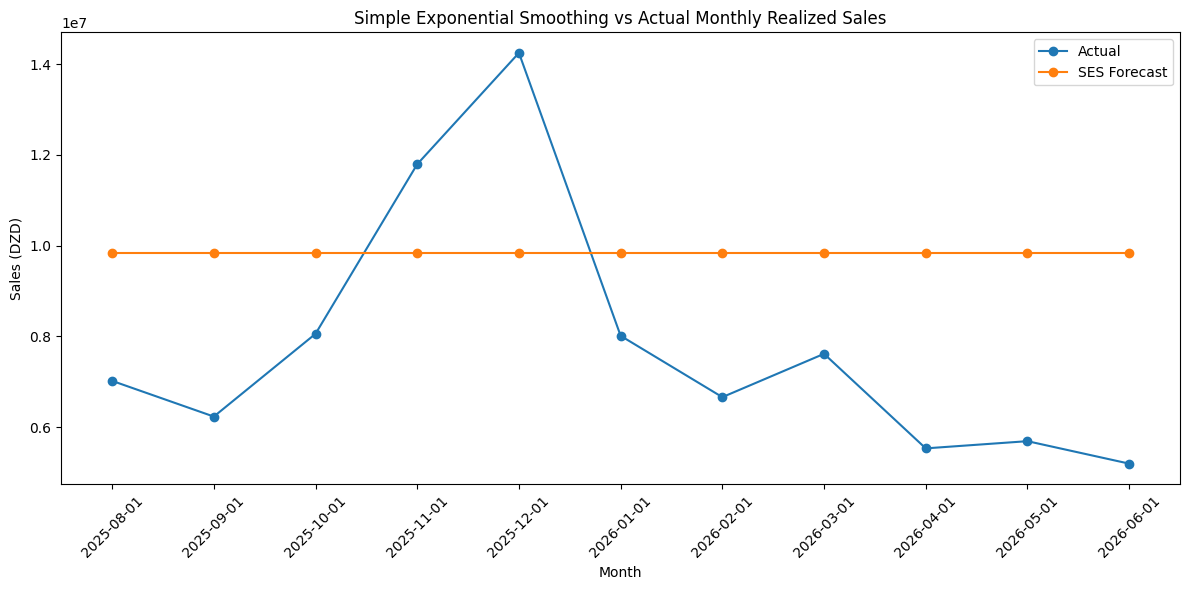

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    test["order_date"].astype(str),
    test["order_total_amount"],
    marker="o",
    label="Actual"
)

plt.plot(
    test["order_date"].astype(str),
    test["ses_forecast"],
    marker="o",
    label="SES Forecast"
)

plt.title("Simple Exponential Smoothing vs Actual Monthly Realized Sales")
plt.xlabel("Month")
plt.ylabel("Sales (DZD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

#### ARIMA Models

ARIMA(1,1,1)
MAE: 2830406.5183145064
RMSE: 3087871.090353541


,order_date,order_total_amount,arima_111_forecast
46,2025-08-01,7021461.80,8.278496e+06
47,2025-09-01,6235186.70,9.836542e+06
48,2025-10-01,8058357.60,9.307731e+06
49,2025-11-01,11793503.60,9.474016e+06
50,2025-12-01,14245785.60,9.420410e+06
51,2026-01-01,8014037.50,9.437555e+06
52,2026-02-01,6663164.42,9.432057e+06
53,2026-03-01,7617337.20,9.433818e+06
54,2026-04-01,5534853.60,9.433254e+06
55,2026-05-01,5693413.70,9.433435e+06


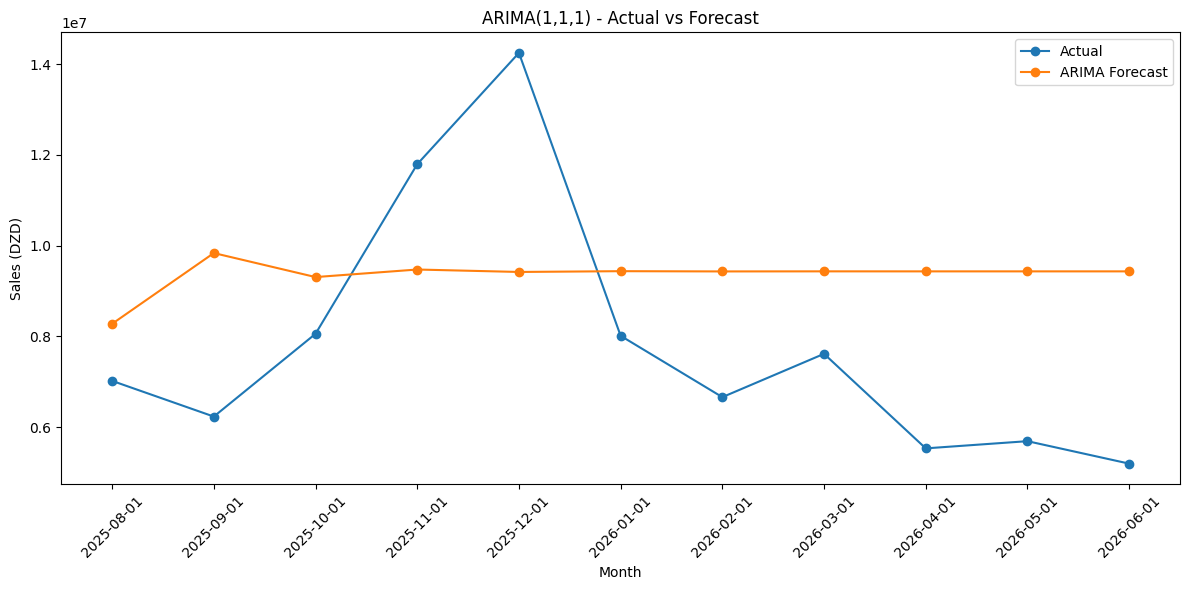

In [ ]:


from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------------
# 1. Prepare the train/test target
# -----------------------------------

train_y = train["order_total_amount"]
test_y = test["order_total_amount"]

# -----------------------------------
# 2. Log transform training data
# -----------------------------------

train_log = np.log(train_y)

# -----------------------------------
# 3. Fit ARIMA
# -----------------------------------

model_111 = ARIMA(
    train_log,
    order=(1, 1, 1)
)

model_fit_111 = model_111.fit()

# -----------------------------------
# 4. Forecast the test period
# -----------------------------------

forecast_111_log = model_fit_111.forecast(
    steps=len(test)
)

# Convert back from log scale to DZD
forecast_111 = np.exp(forecast_111_log)

# Store forecasts
test["arima_111_forecast"] = forecast_111.to_numpy()

# -----------------------------------
# 5. Evaluate ARIMA
# -----------------------------------

mae_111 = mean_absolute_error(
    test_y,
    test["arima_111_forecast"]
)

rmse_111 = np.sqrt(
    mean_squared_error(
        test_y,
        test["arima_111_forecast"]
    )
)

print("ARIMA(1,1,1)")
print("MAE:", mae_111)
print("RMSE:", rmse_111)

# -----------------------------------
# 6. See actual vs forecast
# -----------------------------------

display(
    test[
        [
            "order_date",
            "order_total_amount",
            "arima_111_forecast"
        ]
    ]
)

# -----------------------------------
# 7. Plot
# -----------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    test["order_date"].astype(str),
    test["order_total_amount"],
    marker="o",
    label="Actual"
)

plt.plot(
    test["order_date"].astype(str),
    test["arima_111_forecast"],
    marker="o",
    label="ARIMA Forecast"
)

plt.title("ARIMA(1,1,1) - Actual vs Forecast")
plt.xlabel("Month")
plt.ylabel("Sales (DZD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:


model_211 = ARIMA(
    train_log,
    order=(2, 1, 1)
).fit()

forecast_211_log = model_211.forecast(steps=len(test))

test["arima_211_forecast"] = np.exp(
    forecast_211_log
).to_numpy()

mae_211 = mean_absolute_error(
    test["order_total_amount"],
    test["arima_211_forecast"]
)

rmse_211 = np.sqrt(
    mean_squared_error(
        test["order_total_amount"],
        test["arima_211_forecast"]
    )
)

print("ARIMA(2,1,1)")
print("MAE:", mae_211)
print("RMSE:", rmse_211)

c:\Users\PCPRODZ\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\PCPRODZ\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2,1,1)
MAE: 2876291.3291508895
RMSE: 3157418.777739897


In [ ]:
model_110 = ARIMA(
    train_log,
    order=(1, 1, 0)
).fit()

forecast_110_log = model_110.forecast(steps=len(test))

test["arima_110_forecast"] = np.exp(
    forecast_110_log
).to_numpy()

mae_110 = mean_absolute_error(
    test["order_total_amount"],
    test["arima_110_forecast"]
)

rmse_110 = np.sqrt(
    mean_squared_error(
        test["order_total_amount"],
        test["arima_110_forecast"]
    )
)

print("ARIMA(1,1,0)")
print("MAE:", mae_110)
print("RMSE:", rmse_110)

ARIMA(1,1,0)
MAE: 3060314.6429138826
RMSE: 3330152.6371267857


In [ ]:
baseline_metrics = results.set_index("Model")[["MAE", "RMSE"]].to_dict("index")

forecast_results = pd.DataFrame([
    {"Model": "Average", "MAE": baseline_metrics["Average"]["MAE"], "RMSE": baseline_metrics["Average"]["RMSE"]},
    {"Model": "Naive", "MAE": baseline_metrics["Naive"]["MAE"], "RMSE": baseline_metrics["Naive"]["RMSE"]},
    {"Model": "Seasonal Naive", "MAE": baseline_metrics["Seasonal Naive"]["MAE"], "RMSE": baseline_metrics["Seasonal Naive"]["RMSE"]},
    {"Model": "Drift", "MAE": baseline_metrics["Drift"]["MAE"], "RMSE": baseline_metrics["Drift"]["RMSE"]},
    {"Model": "SES", "MAE": ses_mae, "RMSE": ses_rmse},
    {"Model": "ARIMA(1,1,0)", "MAE": mae_110, "RMSE": rmse_110},
    {"Model": "ARIMA(1,1,1)", "MAE": mae_111, "RMSE": rmse_111},
    {"Model": "ARIMA(2,1,1)", "MAE": mae_211, "RMSE": rmse_211}
]).sort_values("MAE", ascending=True).reset_index(drop=True)

display(forecast_results)

selected_model = forecast_results.loc[0, "Model"]
forecast_column_by_model = {
    "Average": "average_forecast",
    "Naive": "naive_forecast",
    "Seasonal Naive": "seasonal_naive_forecast",
    "Drift": "drift_forecast",
    "SES": "ses_forecast",
    "ARIMA(1,1,0)": "arima_110_forecast",
    "ARIMA(1,1,1)": "arima_111_forecast",
    "ARIMA(2,1,1)": "arima_211_forecast"
}
selected_forecast_column = forecast_column_by_model[selected_model]
test["selected_forecast"] = test[selected_forecast_column]

print("Selected model by lowest MAE:", selected_model)
print("Selected MAE:", forecast_results.loc[0, "MAE"])
print("Selected RMSE:", forecast_results.loc[0, "RMSE"])

fig = px.line(
    test,
    x="order_date",
    y="order_total_amount",
    markers=True,
    title="Actual vs Selected Forecast"
)
fig.add_scatter(
    x=test["order_date"],
    y=test["selected_forecast"],
    mode="lines+markers",
    name="Forecast"
)
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Sales (DZD)"
)
fig.show()


,Model,MAE,RMSE
0,Seasonal Naive,2.585593e+06,3.001609e+06
1,"ARIMA(1,1,1)",2.830407e+06,3.087871e+06
2,Average,2.867641e+06,3.917026e+06
3,"ARIMA(2,1,1)",2.876291e+06,3.157419e+06
4,"ARIMA(1,1,0)",3.060315e+06,3.330153e+06
5,SES,3.176608e+06,3.348769e+06
6,Naive,6.366411e+06,6.891839e+06
7,Drift,8.227591e+06,8.818295e+06


Selected model by lowest MAE: Seasonal Naive
Selected MAE: 2585592.678181818
Selected RMSE: 3001609.357232174


#### Final 3-month forecast

The forecast below uses the model selected by the lowest held-out MAE.

The final forecast anchor is the explicit last complete month (June 2026); July 2026 remains a partial observation excluded from model history and evaluation.

In [ ]:
last_complete_month = COMPLETE_MONTH_END
future_months = pd.date_range(
    start=last_complete_month + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

history = monthly_sales["order_total_amount"]
if selected_model == "Average":
    future_values = np.repeat(history.mean(), 3)
elif selected_model == "Naive":
    future_values = np.repeat(history.iloc[-1], 3)
elif selected_model == "Seasonal Naive":
    history_by_month = {
        month: value
        for month, value in zip(monthly_sales["order_date"].dt.month, history)
    }
    future_values = np.array([
        history_by_month[month]
        for month in future_months.month
    ])
elif selected_model == "Drift":
    drift_per_month = (history.iloc[-1] - history.iloc[0]) / (len(history) - 1)
    future_values = history.iloc[-1] + np.arange(1, 4) * drift_per_month
elif selected_model == "SES":
    final_ses_model = SimpleExpSmoothing(history).fit(optimized=True)
    future_values = final_ses_model.forecast(3).to_numpy()
else:
    arima_orders = {
        "ARIMA(1,1,0)": (1, 1, 0),
        "ARIMA(1,1,1)": (1, 1, 1),
        "ARIMA(2,1,1)": (2, 1, 1)
    }
    final_arima_model = ARIMA(np.log(history), order=arima_orders[selected_model]).fit()
    future_values = np.exp(final_arima_model.forecast(steps=3).to_numpy())

final_forecast = pd.DataFrame({
    "month": future_months,
    "forecast": future_values
})
final_forecast["Model"] = selected_model
final_forecast


,month,forecast,Model
0,2026-07-01,14179432.36,Seasonal Naive
1,2026-08-01,7021461.80,Seasonal Naive
2,2026-09-01,6235186.70,Seasonal Naive


## Decision Summary

- B2C is the largest inferred customer-type segment by realized revenue and order count; other inferred segments have higher average baskets.
- Payment on delivery dominates realized order volume, while Virement_CCP is associated with a much higher average order value.
- Home Delivery leads realized revenue; Pickup Point handles more lower-value orders.
- Order Status Distribution uses all orders and shows 95.26% mapped to Completed.
- The selected forecast model is the tested model with the lowest MAE in forecast_results.
- Free-shipping orders are associated with higher average order values; this result is not causal.

## Analytical Limitations

- customer_type_inferred is inferred rather than verified ground truth.
- has_negative_price is not semantically confirmed as a discount flag and is excluded from finalized business interpretation.
- Free-shipping results are associative, not causal.
- Profitability and margin cannot be calculated without validated COGS.
- Stock or replenishment decisions cannot be made without inventory data.
- Forecasts depend on historical patterns and are not guarantees.